In [6]:
from mipt import *

In [ ]:
x = 4
y = 4
d=4*(x*y)
res = 5
realisations = 5
ps, ents, ent_stds, mis, mi_stds, gmns, gmn_stds = run_2d(x=x, y=y, d=d, res=res, realisations=realisations, p_min=0.0, p_max=0.5)

fig, [ax1, ax2, ax3] = plt.subplots(3, 1, figsize=(10, 8))

props = dict(boxstyle='square', facecolor='white', alpha=0.5)
ax1.text(0.85, 0.95, f"x = {x}, y = {y}\nNo. of Points: {res}\nRealisations: {realisations}", transform=ax1.transAxes, fontsize=10,
        verticalalignment='top', bbox=props)

ax1.errorbar(ps, ents, yerr=ent_stds, fmt='.', color='black', ecolor='black', capsize=3, elinewidth=1)
ax2.errorbar(ps, mis, yerr=mi_stds, fmt='.', color='black', ecolor='black', capsize=3, elinewidth=1)
ax3.errorbar(ps, gmns, yerr=gmn_stds, fmt='.', color='black', ecolor='black', capsize=3, elinewidth=1)
ax3.hlines(0, ps[0], ps[-1], colors='black', linestyles='dashed')
ax1.set_xlabel('Measurement rate $p$')
ax1.set_ylabel('von Neumann Entropy $S$')
ax2.set_xlabel('Measurement rate $p$')
ax2.set_ylabel('Mutual Information $I$')
ax3.set_xlabel('Measurement rate $p$')
ax3.set_ylabel(r'Genuine Multipartite Negativity $\tilde{N}_g$')
plt.tight_layout()

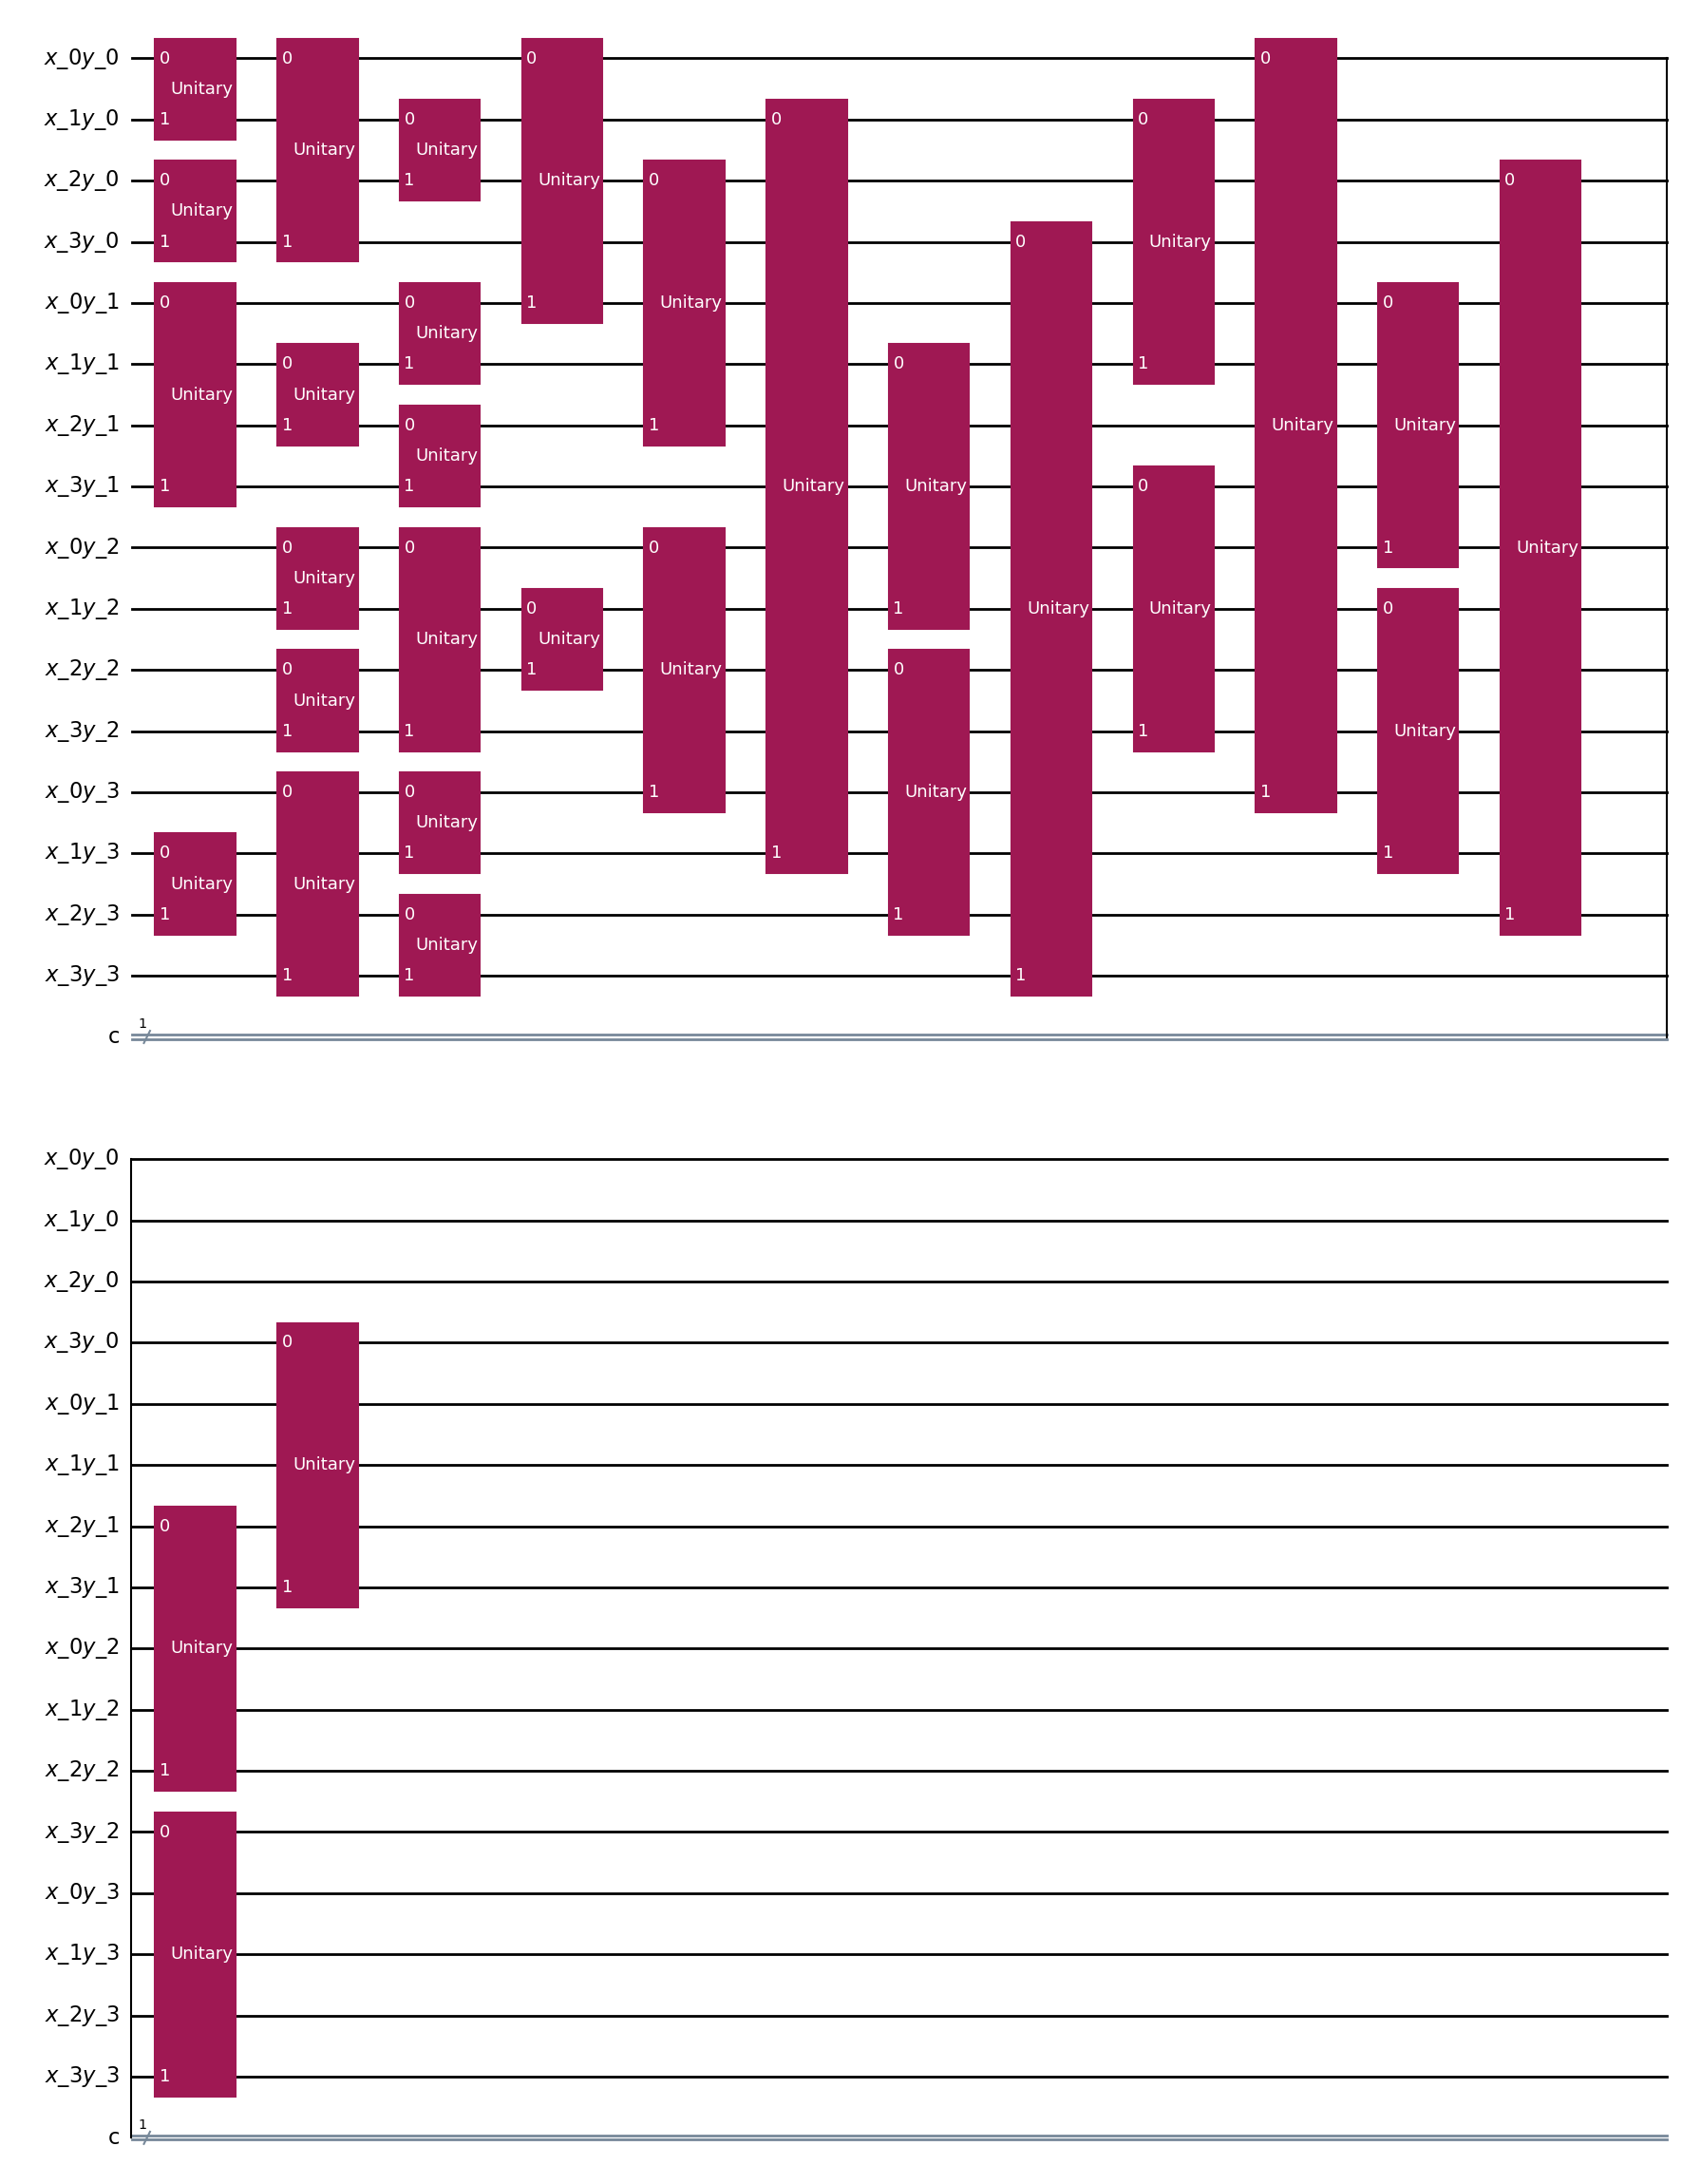

: 

In [ ]:
from mipt import *

qc = random_mipt_2d(x=4, y=4, d=4, p=0)
qc.draw('mpl')
# qc.save_statevector(label='final_state')
# backend = AerSimulator(device='GPU')
# transpiled_qc = transpile(qc, backend)
# result = backend.run(transpiled_qc).result()
# saved_state = result.data(0)['final_state']

# rho = partial_trace(saved_state, [i for i in range(4*4 - 3)])
# print(gmn(rho))

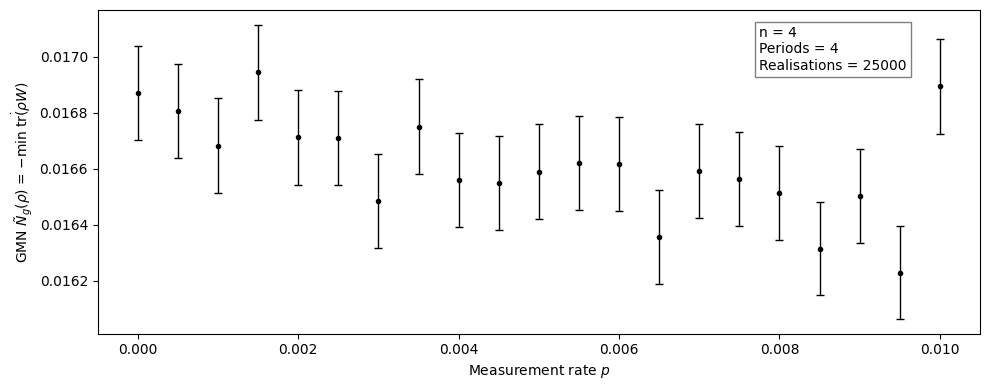

In [2]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt

df = pd.read_csv('data.csv')
data_array = df.to_numpy().transpose()
ps = data_array[0]
# tmi_values = data_array[1]
gmn_values = data_array[1]

df2 = pd.read_csv('info.csv')
data_array2 = df2.to_numpy().transpose()
n = int(data_array2[0][0])
periods = int(data_array2[1][0])
realizations = int(data_array2[2][0])
res = int(data_array2[3][0])
p_min = float(data_array2[4][0])
p_max = float(data_array2[5][0])

ps_unique = list(set(ps))
# tmi_means = []
# tmi_stds = []
gmn_means = []
gmn_stds = []
for p in ps_unique:
    # tmi_values_for_p = [tmi for tmi, p_val in zip(tmi_values, ps) if p_val == p]
    # tmi_means.append(np.mean(tmi_values_for_p))
    # tmi_stds.append(np.std(tmi_values_for_p)/np.sqrt(realizations))
    gmn_values_for_p = [gmn for gmn, p_val in zip(gmn_values, ps) if p_val == p]
    gmn_means.append(np.mean(gmn_values_for_p))
    gmn_stds.append(np.std(gmn_values_for_p, ddof=1)/np.sqrt(realizations*n))

fig, ax1 = plt.subplots(1, 1, figsize=(10, 4))
ax1.errorbar(ps_unique, gmn_means, yerr=gmn_stds, fmt='.', color='black', ecolor='black', capsize=3, elinewidth=1)
# ax2.errorbar(ps_unique, gmn_means, yerr=gmn_stds, fmt='.', color='black', ecolor='black', capsize=3, elinewidth=1)
ax1.set_xlabel('Measurement rate $p$')
ax1.set_ylabel(r'GMN $\tilde{N}_g(\rho)$ = $-\min\;\text{tr}\.(\rho W)$')
# ax2.set_ylabel('GMN')

props = dict(boxstyle='square', facecolor='white', alpha=0.5)
ax1.text(0.75, 0.95, f"n = {n}\nPeriods = {periods}\nRealisations = {realizations}", transform=ax1.transAxes, fontsize=10,
        verticalalignment='top', bbox=props)
 
gmn_means1, gmn_stds1, ps_unique1 = gmn_means, gmn_stds, ps_unique

fig.tight_layout()

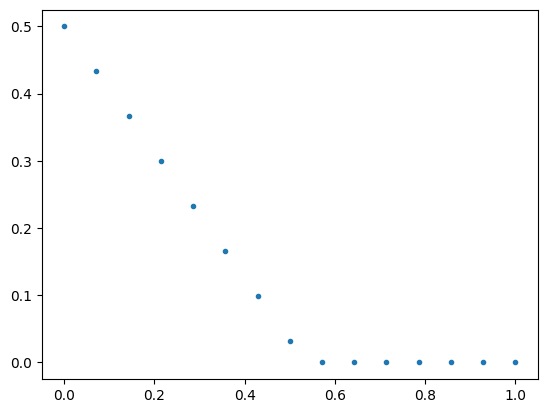

In [2]:
from mipt import *
import numpy as np
from numpy.typing import NDArray
from scipy.optimize import curve_fit

Array = NDArray[np.complex128]

def ghz_white_noise_state(parties: int, p_noise: float) -> np.ndarray:
    """
    rho(p) = (1 - p) |GHZ_n><GHZ_n| + p I / 2**n
    """
    d = 2 ** parties

    psi = np.zeros(d, dtype=np.complex128)
    psi[0] = 1.0 / np.sqrt(2.0)
    psi[-1] = 1.0 / np.sqrt(2.0)

    rho_ghz = np.outer(psi, psi.conj())

    return (1.0 - p_noise) * rho_ghz + p_noise * np.eye(d) / d

ps = np.linspace(0, 1, 15)
gmn_values = []
for p in ps:
    rho = ghz_white_noise_state(parties=4, p_noise=p)
    score = gmn(
            rho,
            parties=4,
            formulation="monotone",
            return_problem=False,
        )
    gmn_values.append(score)

plt.plot(ps, gmn_values, '.')

<ErrorbarContainer object of 3 artists>

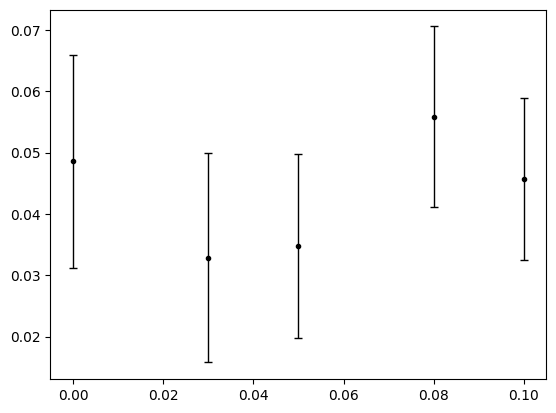

In [7]:
# parties = 4
# partitions = {chr(ord('A') + i): [i] for i in range(parties)}
# print(partitions.items())
import matplotlib.pyplot as plt 

ps = [0.00, 0.03, 0.05, 0.08, 0.10]
means = [0.95139248, 0.96712904, 0.96523922, 0.94411627, 0.95430608]
stderrs = [0.0174, 0.0171, 0.015, 0.0147, 0.0132]

plt.errorbar(ps, [1 - m for m in means], yerr=stderrs, fmt='.', color='black', ecolor='black', capsize=3, elinewidth=1)

Simulating p = 0.05
Simulating d = 1
Simulating d = 2
Simulating d = 3
Simulating p = 0.1625
Simulating d = 1
Simulating d = 2
Simulating d = 3
Simulating p = 0.275
Simulating d = 1
Simulating d = 2
Simulating d = 3
Simulating p = 0.3875
Simulating d = 1
Simulating d = 2
Simulating d = 3
Simulating p = 0.5
Simulating d = 1
Simulating d = 2
Simulating d = 3


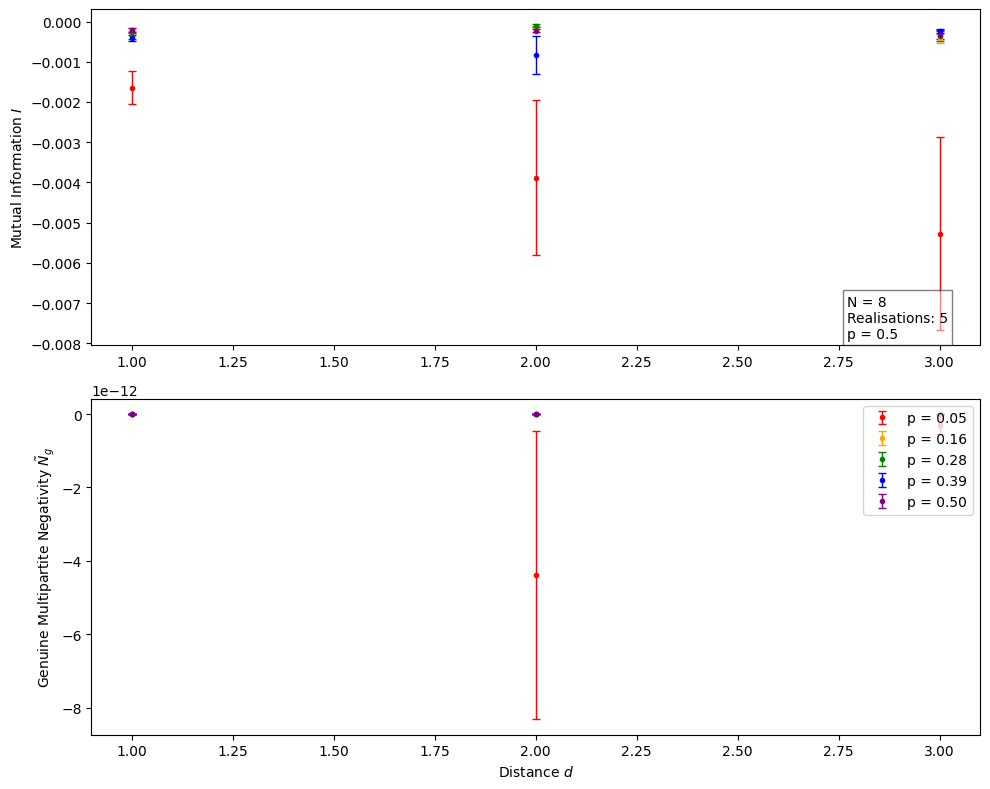

In [4]:
from mipt import *

n = 8
depth = 2*n
ps = np.linspace(0.05, 0.5, 5)
realisations = 5

mi_list, mi_std_list, gmn_list, gmn_std_list = [], [], [], []

for p in ps:
        print("Simulating p =", p)
        d_values, ents, ent_stds, mis, mi_stds, gmns, gmn_stds = run_1d_distance_scan(
                n, depth, p, realisations, d_min=1, d_max=3, use_gpu=False)

        mi_list.append(mis)
        mi_std_list.append(mi_stds)
        gmn_list.append(gmns)
        gmn_std_list.append(gmn_stds)



fig, [ax1, ax2] = plt.subplots(2, 1, figsize=(10, 8))

props = dict(boxstyle='square', facecolor='white', alpha=0.5)
ax1.text(0.85, 0.15, f"N = {n}\nRealisations: {realisations}\np = {p}", transform=ax1.transAxes, fontsize=10,
        verticalalignment='top', bbox=props)

colors = ["red", "orange", "green", "blue", "purple"]
for i in range(len(ps)):        
        ax1.errorbar(d_values, mi_list[i], yerr=mi_std_list[i], fmt='.', color=colors[i], ecolor=colors[i], capsize=3, elinewidth=1)
        ax2.errorbar(d_values, gmn_list[i], yerr=gmn_std_list[i], fmt='.', color=colors[i], ecolor=colors[i], capsize=3, elinewidth=1, label= f"p = {ps[i]:.2f}")
# ax3.hlines(0, d_values[0], d_values[-1], colors='black', linestyles='dashed')
ax2.set_xlabel('Distance $d$')
ax1.set_ylabel('Mutual Information $I$')
ax2.set_ylabel(r'Genuine Multipartite Negativity $\tilde{N}_g$')
ax2.legend(loc='upper right')
plt.tight_layout()

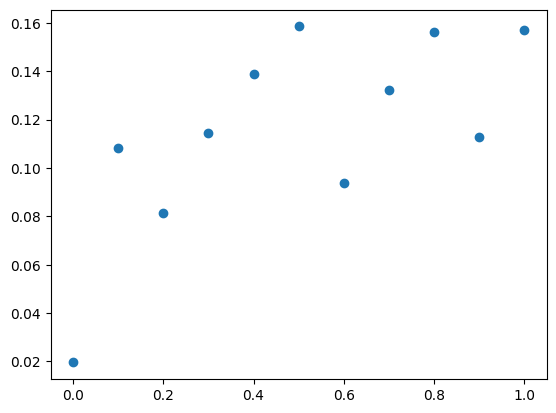

In [2]:
import numpy as np
from mipt import get_mipt_rho_1d, gmn
import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)
import matplotlib.pyplot as plt

from gilbert_uqn_layered_fast_monotone import (
    gilbert_uqn_fast,
    make_triangle_uqn_6q_family,
)

# n = 8
# d = 2*n
# ps = np.linspace(0.0, 1.0, 11)
# vals = []

# for p in ps:
    
#     rhos = get_mipt_rho_1d(n, d, p, subsyst=3, all_matrices=True, closed=True)
#     gmn_scores = [gmn(rho, parties=3) for rho in rhos]
#     print(gmn_scores)
#     idx = max(range(len(gmn_scores)), key=gmn_scores.__getitem__)
#     rho = np.kron(rhos[idx], np.eye(8)/8)

#     rng = np.random.default_rng(1234)

#     family = make_triangle_uqn_6q_family(
#         num_local_layers=1,
#     )

#     result = gilbert_uqn_fast(
#         rho,  # must be 64x64
#         families=[family],
#         rng=rng,
#         max_iter=500,
#         n_random_per_family=2048,
#         n_refine=4,
#         local_maxiter=50,
#         refine=False,
#         memory_size=48,
#         tol_abs=1e-5,
#         tol_rel=1e-5,
#         verbose=True,
#     )
#     val = result.distance
#     print(f"\np = {p} distance: {val}; converged:", {result.converged})
#     vals.append(val)

plt.scatter(ps, vals)

# print("distance:", result.distance)
# print("converged:", result.converged)
# print("stop reason:", result.stop_reason)


In [ ]:
from mipt import *

def max_ent_gate():
    qc = QuantumCircuit(2)
    qc.h(0)
    qc.cx(0, 1)
    return qc
    

def max_ent_mipt_1d(n, d, p, closed=True):
    """n must be even. p must be between 0 and 1."""
    if n % 2 != 0:
        raise ValueError("n must be even")
    if not (0 <= p <= 1):
        raise ValueError("p must be between 0 and 1")
    
    qc = QuantumCircuit(n, n)
    U = max_ent_gate()
    for layer in range(d):

        if (layer % 2 == 0):
            # even layer
            for qubit in range(0, n, 2):
                qc.append(U, [qubit, (qubit + 1)])
        else:
            # odd layer
            if closed:
                qc.append(U, [0, -1])
            for qubit in range(1, n - 1, 2):
                qc.append(U, [qubit, (qubit + 1)])
        
        # random measurements with probability p
        for qubit in range(n):
            if random.random() < p:
                qc.measure(qubit, qubit)

    if (random.random() < 0.5): 
    # 50% chance of an extra even layer at the end
        for qubit in range(0, n, 2):
            qc.append(U, [qubit, (qubit + 1)])
        for qubit in range(n):
            if random.random() < p:
                qc.measure(qubit, qubit)

    return qc

def get_max_ent_mipt_rho_1d(n, d, p, subsyst=3, all_matrices=False, closed=True):

    subsystems = []
    if all_matrices and closed:
        subsystems = [[ (i + j) % n for j in range(subsyst) ] for i in range(n)]
    else:
        subsystems = [list(range(subsyst))]

    backend = AerSimulator(device="CPU", method="matrix_product_state")
    qc = max_ent_mipt_1d(n=n, d=d, p=float(p), closed=closed)

    for i in range(len(subsystems)):
        qc.save_density_matrix(
            qubits=subsystems[i],
            label=f"final_state_{i}",
            pershot=True,
        )

    tqc = transpile(qc, backend)

    # One conditional outcome trajectory for this independently drawn circuit.
    result = backend.run(tqc, shots=1).result()

    if len(subsystems) == 1:
        return result.data(0)["final_state_0"][0]

    data = []
    for i in range(len(subsystems)):
        data.append(result.data(0)[f"final_state_{i}"][0])

    return data

n = 8
d = 2*n
ps = np.linspace(0.0, 1.0, 11)
reps = 5

# means, stderrs = [], []
gmns = []

for p in ps:
    print(f"p = {p}:")
    # for _ in reps:
    rhos = get_max_ent_mipt_rho_1d(n, d, p, all_matrices=True)
    print(rhos)
    print([gmn(rho, parties=3) for rho in rhos])

# print(gmns)





p = 0.0:
[DensityMatrix([[ 1.25000000e-01+0.j, -5.76795556e-17+0.j,
                 9.36750677e-17+0.j,  1.56667214e-16+0.j,
                 1.27068495e-16+0.j, -1.79814930e-16+0.j,
                -1.74773390e-16+0.j, -3.68865908e-17+0.j],
               [-5.76795556e-17+0.j,  1.25000000e-01+0.j,
                -1.70002901e-16+0.j, -9.36750677e-17+0.j,
                -1.83880688e-16+0.j,  1.30104261e-16+0.j,
                 3.12250226e-17+0.j,  1.69406589e-16+0.j],
               [ 9.36750677e-17+0.j, -1.70002901e-16+0.j,
                 1.25000000e-01+0.j, -2.86229374e-17+0.j,
                 8.15320034e-17+0.j, -1.26201133e-16+0.j,
                -9.71445147e-17+0.j,  1.34983170e-17+0.j],
               [ 1.56667214e-16+0.j, -9.36750677e-17+0.j,
                -2.86229374e-17+0.j,  1.25000000e-01+0.j,
                 1.23165367e-16+0.j, -7.35089073e-17+0.j,
                 1.56125113e-17+0.j, -1.05303136e-16+0.j],
               [ 1.27068495e-16+0.j, -1.83880688e-16+0.j,


KeyboardInterrupt: 

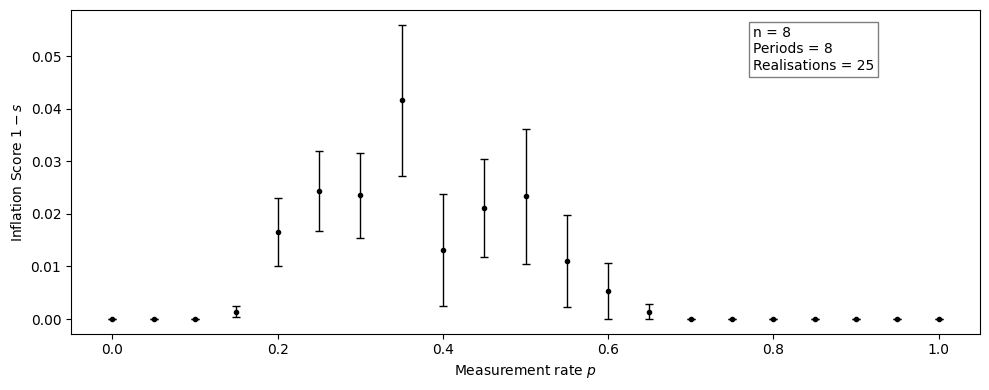

In [9]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt

df = pd.read_csv('runs/gnme/gnme_n_8_real_25.csv')
data_array = df.to_numpy().transpose()
ps = data_array[0]
infl_values = data_array[1]

# df2 = pd.read_csv('info.csv')
# data_array2 = df2.to_numpy().transpose()

n = 8
periods = 8
realizations = 25


# n = int(data_array2[0][0])
# periods = int(data_array2[1][0])
# realizations = int(data_array2[2][0])
# res = int(data_array2[3][0])
# p_min = float(data_array2[4][0])
# p_max = float(data_array2[5][0])

ps_unique = list(set(ps))
# tmi_means = []
# tmi_stds = []
means = []
stds = []
for p in ps_unique:
    infl_values_for_p = [infl for infl, p_val in zip(infl_values, ps) if p_val == p]
    means.append(np.mean(infl_values_for_p))
    stds.append(np.std(infl_values_for_p, ddof=1)/np.sqrt(realizations))

fig, ax1 = plt.subplots(1, 1, figsize=(10, 4))
ax1.errorbar(ps_unique, [1 - m for m in means], yerr=stds, fmt='.', color='black', ecolor='black', capsize=3, elinewidth=1)
ax1.set_xlabel('Measurement rate $p$')
ax1.set_ylabel(r'Inflation Score $1 - s$')

props = dict(boxstyle='square', facecolor='white', alpha=0.5)
ax1.text(0.75, 0.95, f"n = {n}\nPeriods = {periods}\nRealisations = {realizations}", transform=ax1.transAxes, fontsize=10,
        verticalalignment='top', bbox=props)
 

fig.tight_layout()

In [8]:
print(np.linspace(0.65, 1.0, 8))

[0.65 0.7  0.75 0.8  0.85 0.9  0.95 1.  ]
